In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Proteins unfold when they are cold, too: six figures from one stability curve (Illustrations 15.5-1 and 15.5-2, Figures 15.5-1 to 15.5-6)

$$\Delta_{\rm unf}G(T)=\Delta_{\rm unf}H(T_m)\left(1-\frac{T}{T_m}\right)
+\Delta_{\rm unf}C_P\left(T-T_m-T\ln\frac{T}{T_m}\right)$$

Every figure in Sec. 15.5 comes out of that one equation, and the whole section turns on the fact
that it is **not linear in temperature**. A linear $\Delta G(T)$ crosses zero once. This one is a
downward parabola-like curve that crosses zero **twice** — so a protein has a *cold* denaturation
temperature as well as a hot one, and a temperature of maximum stability in between at which
$\Delta_{\rm unf}S = 0$ exactly.

Four proteins, one model:

| | protein | $T_m$ | what it shows |
|---|---|---|---|
| **15.5-1** | G-actin | 330.0 K | the $C_P$ term is what puts $T_m$ where it is |
| Figs. 15.5-1 to 15.5-3 | metmyoglobin | 274 and 323 K | the two roots, and $\Delta G$ two orders below $\Delta H$ |
| Fig. 15.5-4 | human prion | ~343 K | why prions are hard to destroy |
| Figs. 15.5-5, 15.5-6 | $\beta$-lactoglobulin | 250 and 351 K | a 101 K stability range, and what urea does to it |
| **15.5-2** | DPPC | 313 K | the pressure branch: Eq. 15.5-5 is Eq. 7.7-4 for a protein |

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.append("..")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from thermo.charts import use_book_style

use_book_style()
os.makedirs("pdf", exist_ok=True)

R = 8.314
T25 = 298.15
CAL = 4.184           # J per calorie
FIG_W = 3.4

## The stability curve, and its two forms

Sec. 15.5 writes Eq. 15.5-1 referred to 25 $^\circ$C (a $\Delta G$, a $\Delta H$ and a $\Delta C_P$
at that temperature) and Sec. 15.2 writes the same function referred to $T_m$ (Eq. 15.2-16). They are
the same equation, and the notebook uses whichever the data are quoted in — but it **checks** that
they agree rather than asserting it, because the two carry different signs on the $C_P$ term and it
is easy to transcribe one into the other wrongly.

In [3]:
def dG_from_ref(T, dG_ref, dH_ref, dCp, T_ref=T25):
    """Eq. 15.5-1, referred to a temperature where dG and dH are both known."""
    T = np.asarray(T, float)
    dS_ref = (dH_ref - dG_ref) / T_ref
    return (dH_ref + dCp * (T - T_ref)) - T * (dS_ref + dCp * np.log(T / T_ref))


def dG_from_Tm(T, T_m, dH_m, dCp):
    """Eq. 15.2-16, referred to the melting temperature, where dG = 0."""
    T = np.asarray(T, float)
    return dH_m * (1.0 - T / T_m) + dCp * (T - T_m - T * np.log(T / T_m))


def ln_K(T, dG_ref, dH_ref, dCp, T_ref=T25):
    """The printed form of Eq. 15.5-1: ln K written out term by term."""
    T = np.asarray(T, float)
    return (-dG_ref / (R * T_ref) - dH_ref / R * (1.0 / T - 1.0 / T_ref)
            + dCp / R * (np.log(T / T_ref) + T_ref / T - 1.0))


def alpha(dG, T):
    """Eq. 15.5-3: the fraction unfolded, from dG_unf."""
    x = np.exp(-np.asarray(dG, float) / (R * np.asarray(T, float)))
    return x / (1.0 + x)


# The three routes must be the same function. Check it, do not claim it.
T_probe = np.linspace(260.0, 360.0, 51)
a = dG_from_ref(T_probe, 27_000.0, 197_000.0, 5378.0)
b = -R * T_probe * ln_K(T_probe, 27_000.0, 197_000.0, 5378.0)
Tm_probe = brentq(lambda T: dG_from_ref(T, 27_000.0, 197_000.0, 5378.0), 300.0, 400.0)
c = dG_from_Tm(T_probe, Tm_probe,
               float(dG_from_ref(Tm_probe, 27_000.0, 197_000.0, 5378.0)
                     + Tm_probe * (197_000.0 - 27_000.0) / T25), 5378.0)
print(f"  max |Eq. 15.5-1 as dG  -  as ln K| = {np.max(np.abs(a - b)):.3e} J/mol")
assert np.max(np.abs(a - b)) < 1e-6
dH_at_Tm = 197_000.0 + 5378.0 * (Tm_probe - T25)
c = dG_from_Tm(T_probe, Tm_probe, dH_at_Tm, 5378.0)
print(f"  max |referred to 25 C  -  referred to T_m|      = "
      f"{np.max(np.abs(a - c)):.3e} J/mol")
assert np.max(np.abs(a - c)) < 1e-6

  max |Eq. 15.5-1 as dG  -  as ln K| = 3.420e-10 J/mol
  max |referred to 25 C  -  referred to T_m|      = 3.456e-10 J/mol


## Illustration 15.5-1 — G-actin, and a heat capacity that cannot be right

The illustration gives $\Delta_{\rm unf}G=27$ kJ/mol, $\Delta_{\rm unf}H=197$ kJ/mol and
$\Delta_{\rm unf}C_P=27$ J/(mol K) at 25 $^\circ$C, then solves $\ln K(T_m)=0$ and reports
$T_m=330.0$ K $=56.8\ ^\circ$C against a measured 57.1 $^\circ$C.

**The two printed heat capacities are different numbers and neither gives 330.0 K.** The data line
says 27 J/(mol K); the displayed equation two lines below substitutes `54 000/R`. The cell below runs
the solve at both, and then inverts it — solving for the $\Delta C_P$ that *does* produce the
printed answer.

In [4]:
DG_ACTIN, DH_ACTIN = 27_000.0, 197_000.0


def Tm_actin(dCp):
    return brentq(lambda T: ln_K(T, DG_ACTIN, DH_ACTIN, dCp), 299.0, 600.0)


rows = []
for dCp, where in ((27.0, "the data line, J/(mol K)"),
                   (54_000.0, "the displayed equation, J/(mol K)"),
                   (5_400.0, "5.4 kJ/(mol K)")):
    Tm = Tm_actin(dCp)
    rows.append((where, dCp, Tm, Tm - 273.15))
dCp_actin = brentq(lambda c: Tm_actin(c) - 330.0, 100.0, 40_000.0)
rows.append((f"inverted from T_m = 330.0 K", dCp_actin, Tm_actin(dCp_actin),
             Tm_actin(dCp_actin) - 273.15))
print(pd.DataFrame(rows, columns=["dCp taken from", "dCp, J/(mol K)", "T_m, K",
                                  "T_m, C"]).to_string(index=False,
                                                       float_format=lambda v: f"{v:.4g}"))
print(f"\n  the illustration prints T_m = 330.0 K = 56.8 C, measured 57.1 C")
print(f"  the value that reproduces it is {dCp_actin:.0f} J/(mol K) = "
      f"{dCp_actin / 1000:.2f} kJ/(mol K)")
print(f"  for scale: beta-lactoglobulin's, four figures later, is 5.58 kJ/(mol K)")
assert abs(Tm_actin(5_400.0) - 330.0) < 0.05

                   dCp taken from  dCp, J/(mol K)  T_m, K  T_m, C
         the data line, J/(mol K)              27   345.3   72.19
the displayed equation, J/(mol K)         5.4e+04   312.6    39.5
                   5.4 kJ/(mol K)            5400     330   56.82
      inverted from T_m = 330.0 K            5378     330   56.85

  the illustration prints T_m = 330.0 K = 56.8 C, measured 57.1 C
  the value that reproduces it is 5378 J/(mol K) = 5.38 kJ/(mol K)
  for scale: beta-lactoglobulin's, four figures later, is 5.58 kJ/(mol K)


  wrote pdf/c15uf005.pdf
     5 to   95 percent unfolded: 322.5 to 337.0 K, i.e. 14.5 K
     1 to   99 percent unfolded: 318.0 to 340.8 K, i.e. 22.7 K
  Illustration 15.5-1: 'unfolding of G-actin occurs over a temperature interval
  of more than 20 C' -- true at the 1-to-99 percent reading, not at 5-to-95


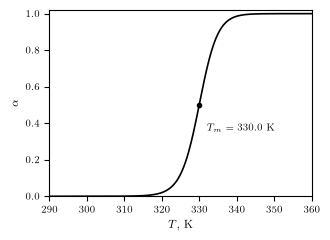

In [5]:
DCP_ACTIN = 5_400.0            # kJ/(mol K) x 1000 -- see the cell above
T = np.linspace(290.0, 360.0, 601)
a_actin = alpha(dG_from_ref(T, DG_ACTIN, DH_ACTIN, DCP_ACTIN), T)

fig, ax = plt.subplots(figsize=(FIG_W, 2.5))
ax.plot(T, a_actin, "k", lw=1.2)
Tm = Tm_actin(DCP_ACTIN)
ax.plot([Tm], [0.5], "ko", ms=3)
ax.annotate(rf"$T_m={Tm:.1f}$ K", xy=(Tm, 0.5), xytext=(Tm + 2, 0.36), fontsize=7)
ax.set_xlabel(r"$T$, K", fontsize=8)
ax.set_ylabel(r"$\alpha$", fontsize=8)
ax.set_xlim(290, 360)
ax.set_ylim(0, 1.02)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15uf005.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/c15uf005.pdf")

g = lambda t, f: alpha(dG_from_ref(t, DG_ACTIN, DH_ACTIN, DCP_ACTIN), t) - f
for f_lo, f_hi in ((0.05, 0.95), (0.01, 0.99)):
    lo = brentq(g, 280.0, Tm, args=(f_lo,))
    hi = brentq(g, Tm, 400.0, args=(f_hi,))
    print(f"  {100 * f_lo:4.0f} to {100 * f_hi:4.0f} percent unfolded: {lo:.1f} to "
          f"{hi:.1f} K, i.e. {hi - lo:.1f} K")
print("  Illustration 15.5-1: 'unfolding of G-actin occurs over a temperature interval")
print("  of more than 20 C' -- true at the 1-to-99 percent reading, not at 5-to-95")

## Metmyoglobin — Figures 15.5-1, 15.5-2 and 15.5-3

Privalov and Khechinashvili's data, read off their graph and kept in their units:
$\Delta_{\rm unf}C_P = 0.16$ cal/(g K) and $\Delta_{\rm unf}H(50\ ^\circ\mathrm{C}) = 4.1$ cal/g. The
section reports four numbers from these two, and all four fall out of the stability curve with no
further input: cold denaturation at 274 K, hot at 323 K, maximum stability at 298.5 K, and a peak
$\Delta_{\rm unf}G$ of about 0.158 cal/g.

The 50 $^\circ$C at which $\Delta H$ is quoted *is* the hot denaturation temperature — 323.15 K —
which is what closes the problem: at $T_m$, $\Delta S = \Delta H/T_m$, so one enthalpy and one heat
capacity fix the whole curve.

In [6]:
TM_MET, DH_MET, DCP_MET = 323.15, 4.1, 0.16          # K, cal/g, cal/(g K)

T = np.linspace(255.0, 345.0, 901)
dG_met = dG_from_Tm(T, TM_MET, DH_MET, DCP_MET)
dH_met = DH_MET + DCP_MET * (T - TM_MET)
TdS_met = dH_met - dG_met

T_cold = brentq(lambda t: dG_from_Tm(t, TM_MET, DH_MET, DCP_MET), 240.0, 315.0)
T_max = TM_MET * np.exp(-(DH_MET / TM_MET) / DCP_MET)
dG_max = float(dG_from_Tm(T_max, TM_MET, DH_MET, DCP_MET))
print(f"  cold denaturation    {T_cold:7.2f} K     printed 274 K")
print(f"  hot denaturation     {TM_MET:7.2f} K     printed 323 K")
print(f"  maximum stability    {T_max:7.2f} K     printed 298.5 K")
print(f"  dG there             {dG_max:7.4f} cal/g   printed 0.158 cal/g")
print(f"  stability range      {TM_MET - T_cold:7.2f} K     'compared with 49 K "
      f"(274 to 323 K)'")
print(f"\n  dG_max = 0.158 cal/g is quoted as 11.2 kJ/mol, which implies")
print(f"  M = {11_200 / (dG_max * CAL):.0f} g/mol -- metmyoglobin is about 17 000")
assert abs(T_cold - 274.0) < 1.0 and abs(T_max - 298.5) < 0.1
assert abs(dG_max - 0.158) < 5e-4

  cold denaturation     274.54 K     printed 274 K
  hot denaturation      323.15 K     printed 323 K
  maximum stability     298.51 K     printed 298.5 K
  dG there              0.1583 cal/g   printed 0.158 cal/g
  stability range        48.61 K     'compared with 49 K (274 to 323 K)'

  dG_max = 0.158 cal/g is quoted as 11.2 kJ/mol, which implies
  M = 16905 g/mol -- metmyoglobin is about 17 000


  wrote pdf/c15f008.pdf and pdf/c15f009.pdf  (Figures 15.5-1 and 15.5-2)
  ratio of scales: |dH| peaks at 7.60 cal/g against |dG| at 0.393 -- a factor of 19


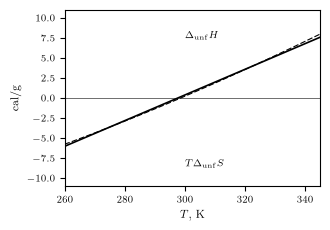

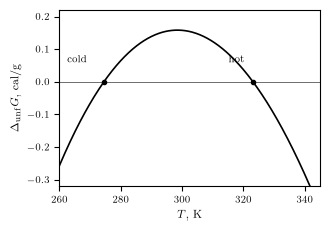

In [7]:
# c15f008 is Figure 15.5-1, c15f009 is Figure 15.5-2. One slot, one file.
fig, ax = plt.subplots(figsize=(FIG_W, 2.4))
ax.plot(T, dH_met, "k", lw=1.2)
ax.plot(T, TdS_met, "k", lw=0.8, ls=(0, (5, 2)))
ax.axhline(0.0, color="k", lw=0.4)
ax.text(300, 7.5, r"$\Delta_{\rm unf}H$", fontsize=7)
ax.text(300, -8.5, r"$T\Delta_{\rm unf}S$", fontsize=7)
ax.set_xlabel(r"$T$, K", fontsize=8)
ax.set_ylabel("cal/g", fontsize=8)
ax.set_xlim(260, 345)
ax.set_ylim(-11, 11)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15f008.pdf", dpi=300, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(FIG_W, 2.4))
ax.plot(T, dG_met, "k", lw=1.2)
ax.axhline(0.0, color="k", lw=0.4)
for t in (T_cold, TM_MET):
    ax.plot([t], [0.0], "ko", ms=3)
ax.annotate("cold", xy=(T_cold, 0), xytext=(T_cold - 12, 0.06), fontsize=7)
ax.annotate("hot", xy=(TM_MET, 0), xytext=(TM_MET - 8, 0.06), fontsize=7)
ax.set_xlabel(r"$T$, K", fontsize=8)
ax.set_ylabel(r"$\Delta_{\rm unf}G$, cal/g", fontsize=8)
ax.set_xlim(260, 345)
ax.set_ylim(-0.32, 0.22)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15f009.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/c15f008.pdf and pdf/c15f009.pdf  (Figures 15.5-1 and 15.5-2)")
print(f"  ratio of scales: |dH| peaks at {np.max(np.abs(dH_met)):.2f} cal/g against "
      f"|dG| at {np.max(np.abs(dG_met)):.3f} -- a factor of "
      f"{np.max(np.abs(dH_met)) / np.max(np.abs(dG_met)):.0f}")

Figure 15.5-1's printed caption says the units are kcal/g. The numbers on its axis run
$-10$ to $+10$ and the data are 4.1 cal/g at $T_m$, so the axis is **cal/g** — a protein whose
unfolding enthalpy were 4.1 kcal/g would be releasing 70 MJ per mole.

Now the fraction denatured, Figure 15.5-3. Converting to a molar basis needs a molecular weight; the
section supplies one implicitly by quoting 0.158 cal/g as 11.2 kJ/mol, which is 17 000 g/mol.

  wrote pdf/c15f010.pdf  (Figure 15.5-3), on M = 16905 g/mol
  alpha at the temperature of maximum stability: 0.0108


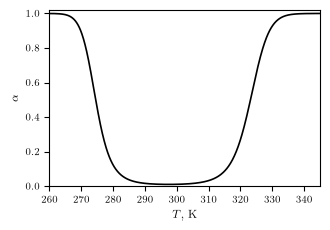

In [8]:
MW_MET = 11_200.0 / (dG_max * CAL)          # g/mol, implied by the section's own pair

a_met = alpha(dG_met * CAL * MW_MET, T)
fig, ax = plt.subplots(figsize=(FIG_W, 2.4))
ax.plot(T, a_met, "k", lw=1.2)
ax.set_xlabel(r"$T$, K", fontsize=8)
ax.set_ylabel(r"$\alpha$", fontsize=8)
ax.set_xlim(260, 345)
ax.set_ylim(0, 1.02)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15f010.pdf", dpi=300, bbox_inches="tight")
print(f"  wrote pdf/c15f010.pdf  (Figure 15.5-3), on M = {MW_MET:.0f} g/mol")
print(f"  alpha at the temperature of maximum stability: {float(alpha(dG_max * CAL * MW_MET, T_max)):.4f}")

## The human prion — Figure 15.5-4, and a datum that has to be read the other way

Swietnicki *et al.* give $\Delta_{\rm unf}G=26.3$ kJ/mol, $\Delta_{\rm unf}H=294$ kJ/mol and a
denaturation temperature of about 70 $^\circ$C. Those three are not simultaneously consistent with a
$\Delta G$ and $\Delta H$ both quoted at 25 $^\circ$C: that pair alone puts $T_m$ at 54.3 $^\circ$C,
and **no non-negative $\Delta C_P$ moves it up**, because a positive $\Delta C_P$ makes the protein
*less* stable at high temperature, not more.

Read $\Delta H = 294$ kJ/mol as the enthalpy **at the melting temperature** instead — which is how
calorimetry reports it, and how Privalov and Khechinashvili's metmyoglobin numbers were quoted four
paragraphs earlier — and the three data close on a $\Delta C_P$ of about 3.9 kJ/(mol K), which is
where a protein of that size belongs. That is the reading the cell below uses, and it is the one
Figure 15.5-4's own axis (320 to 380 K) agrees with.

  reading dH as the value at 25 C, with dCp = 0:  T_m = 327.44 K = 54.3 C
    and at dCp = 5 kJ/(mol K):                     T_m = 322.19 K -- moving the WRONG way

  reading dH as the value at T_m = 343.15 K:
    dCp = 3967 J/(mol K) = 3.97 kJ/(mol K)
    dG(25 C) = 26.30 kJ/mol      given 26.3
    cold denaturation at 214.8 K, so the stability range is 128 K


  wrote pdf/c15f011.pdf  (Figure 15.5-4)


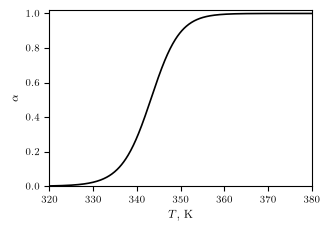

In [9]:
DG25_PRION, DH_PRION, TM_PRION = 26_300.0, 294_000.0, 343.15

Tm_if_25C = brentq(lambda t: ln_K(t, DG25_PRION, DH_PRION, 0.0), 299.0, 500.0)
print(f"  reading dH as the value at 25 C, with dCp = 0:  T_m = {Tm_if_25C:.2f} K = "
      f"{Tm_if_25C - 273.15:.1f} C")
print(f"    and at dCp = 5 kJ/(mol K):                     T_m = "
      f"{brentq(lambda t: ln_K(t, DG25_PRION, DH_PRION, 5000.0), 299.0, 500.0):.2f} K "
      f"-- moving the WRONG way")

# dH at T_m: solve dCp from dG(25 C) = 26.3 kJ/mol.
dCp_prion = brentq(
    lambda c: dG_from_Tm(T25, TM_PRION, DH_PRION, c) - DG25_PRION, 0.0, 40_000.0)
print(f"\n  reading dH as the value at T_m = {TM_PRION:.2f} K:")
print(f"    dCp = {dCp_prion:.0f} J/(mol K) = {dCp_prion / 1000:.2f} kJ/(mol K)")
print(f"    dG(25 C) = {float(dG_from_Tm(T25, TM_PRION, DH_PRION, dCp_prion)) / 1000:.2f} "
      f"kJ/mol      given 26.3")
T_cold_prion = brentq(lambda t: dG_from_Tm(t, TM_PRION, DH_PRION, dCp_prion),
                      200.0, 330.0)
print(f"    cold denaturation at {T_cold_prion:.1f} K, so the stability range is "
      f"{TM_PRION - T_cold_prion:.0f} K")

T = np.linspace(320.0, 380.0, 601)
fig, ax = plt.subplots(figsize=(FIG_W, 2.4))
ax.plot(T, alpha(dG_from_Tm(T, TM_PRION, DH_PRION, dCp_prion), T), "k", lw=1.2)
ax.set_xlabel(r"$T$, K", fontsize=8)
ax.set_ylabel(r"$\alpha$", fontsize=8)
ax.set_xlim(320, 380)
ax.set_ylim(0, 1.02)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15f011.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/c15f011.pdf  (Figure 15.5-4)")

## $\beta$-lactoglobulin — Figures 15.5-5 and 15.5-6, and what urea does

Griko and Privalov, at pH 2: $\Delta_{\rm unf}H = 312$ kJ/mol at $T_m = 351$ K and
$\Delta_{\rm unf}C_P = 5.58$ kJ/(mol K). The section reports a predicted cold denaturation
temperature of 250 K and a 101 K stability range against metmyoglobin's 49 K.

The 2 M urea curves need one more parameter the section does not print. The standard treatment —
Santoro and Bolen's linear extrapolation model, which Problem 15.5 cites — is that a chemical
denaturant shifts the whole stability curve down by an amount proportional to its concentration,
$\Delta G_{\rm unf}(T,C)=\Delta G_{\rm unf}(T,0)-mC$. The cell below inverts the section's own
statement (*"the range of thermal stability is reduced by more than 30 $^\circ$C"*) for $m$, which
is the honest way to draw the dashed curves until Griko and Privalov's own numbers are in hand.

In [10]:
TM_BLG, DH_BLG, DCP_BLG = 351.0, 312_000.0, 5_580.0

T_cold_blg = brentq(lambda t: dG_from_Tm(t, TM_BLG, DH_BLG, DCP_BLG), 180.0, 340.0)
T_max_blg = TM_BLG * np.exp(-(DH_BLG / TM_BLG) / DCP_BLG)
print(f"  cold denaturation   {T_cold_blg:7.2f} K    printed 250 K")
print(f"  hot  denaturation   {TM_BLG:7.2f} K    printed 351 K")
print(f"  stability range     {TM_BLG - T_cold_blg:7.2f} K    printed 101 K "
      f"(metmyoglobin's is {TM_MET - T_cold:.0f} K)")
print(f"  maximum stability   {T_max_blg:7.2f} K, dG = "
      f"{float(dG_from_Tm(T_max_blg, TM_BLG, DH_BLG, DCP_BLG)) / 1000:.1f} kJ/mol")
assert abs(T_cold_blg - 250.0) < 1.0


def range_with_offset(offset):
    """Hot minus cold denaturation temperature when dG is shifted down by `offset`."""
    f = lambda t: dG_from_Tm(t, TM_BLG, DH_BLG, DCP_BLG) - offset
    return (brentq(f, T_max_blg, 420.0) - brentq(f, 180.0, T_max_blg))


offset = brentq(lambda d: range_with_offset(d) - (TM_BLG - T_cold_blg - 30.0),
                0.0, 20_000.0)
UREA = 2.0
print(f"\n  a 30 K reduction needs dG shifted down by {offset / 1000:.2f} kJ/mol,")
print(f"  i.e. m = {offset / 1000 / UREA:.2f} kJ/(mol M) at 2 M urea -- which is inside")
print(f"  the range Santoro and Bolen report for globular proteins")
f = lambda t: dG_from_Tm(t, TM_BLG, DH_BLG, DCP_BLG) - offset
print(f"  with urea: cold {brentq(f, 180.0, T_max_blg):.1f} K, hot "
      f"{brentq(f, T_max_blg, 420.0):.1f} K")

  cold denaturation    250.44 K    printed 250 K
  hot  denaturation    351.00 K    printed 351 K
  stability range      100.56 K    printed 101 K (metmyoglobin's is 49 K)
  maximum stability    299.31 K, dG = 23.6 kJ/mol

  a 30 K reduction needs dG shifted down by 11.98 kJ/mol,
  i.e. m = 5.99 kJ/(mol M) at 2 M urea -- which is inside
  the range Santoro and Bolen report for globular proteins
  with urea: cold 264.7 K, hot 335.3 K


  wrote pdf/c15f012.pdf and pdf/c15f013.pdf  (Figures 15.5-5 and 15.5-6)
  the urea curves are the linear extrapolation model with m inverted from the
  section's own '30 C' -- replace it when Griko and Privalov's value is in hand


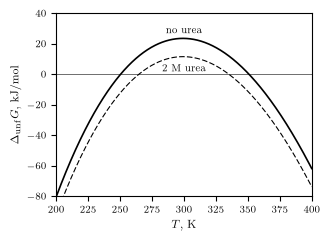

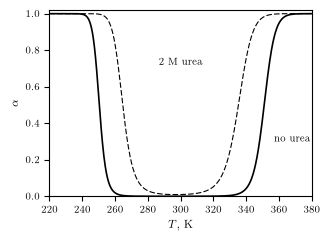

In [11]:
T = np.linspace(200.0, 400.0, 801)
dG0 = dG_from_Tm(T, TM_BLG, DH_BLG, DCP_BLG) / 1000.0
dGu = dG0 - offset / 1000.0

fig, ax = plt.subplots(figsize=(FIG_W, 2.5))
ax.plot(T, dG0, "k", lw=1.2)
ax.plot(T, dGu, "k", lw=0.8, ls=(0, (5, 2)))
ax.axhline(0.0, color="k", lw=0.4)
ax.set_xlabel(r"$T$, K", fontsize=8)
ax.set_ylabel(r"$\Delta_{\rm unf}G$, kJ/mol", fontsize=8)
ax.set_xlim(200, 400)
ax.set_ylim(-80, 40)
ax.tick_params(labelsize=7)
ax.text(300, 27, "no urea", fontsize=7, ha="center")
ax.text(300, 2, "2 M urea", fontsize=7, ha="center")
fig.tight_layout()
fig.savefig("pdf/c15f012.pdf", dpi=300, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(FIG_W, 2.5))
T2 = np.linspace(220.0, 380.0, 801)
ax.plot(T2, alpha(dG_from_Tm(T2, TM_BLG, DH_BLG, DCP_BLG), T2), "k", lw=1.2)
ax.plot(T2, alpha(dG_from_Tm(T2, TM_BLG, DH_BLG, DCP_BLG) - offset, T2),
        "k", lw=0.8, ls=(0, (5, 2)))
ax.text(357, 0.30, "no urea", fontsize=7, ha="left")
ax.text(300, 0.72, "2 M urea", fontsize=7, ha="center")
ax.set_xlabel(r"$T$, K", fontsize=8)
ax.set_ylabel(r"$\alpha$", fontsize=8)
ax.set_xlim(220, 380)
ax.set_ylim(0, 1.02)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15f013.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/c15f012.pdf and pdf/c15f013.pdf  (Figures 15.5-5 and 15.5-6)")
print("  the urea curves are the linear extrapolation model with m inverted from the")
print("  section's own '30 C' -- replace it when Griko and Privalov's value is in hand")

## Illustration 15.5-2 — the pressure branch

$$\left(\frac{dP}{dT}\right)_{\!G_{\rm nat}=G_{\rm unf}}
=\frac{\Delta_{\rm unf}S}{\Delta_{\rm unf}V}=\frac{\Delta_{\rm unf}H}{T_m\,\Delta_{\rm unf}V}$$

Eq. 15.5-5 is the Clapeyron equation, Eq. 7.7-4, with "unfolded" in place of "vapor". DPPC melts at
313 K at 1.013 bar, $dT_m/dP = 0.04$ K/bar, $\Delta_{\rm unf}V = 26$ cm$^3$/mol.

In [12]:
TM_DPPC, DTDP_DPPC, DV_DPPC = 313.0, 0.04, 26.0e-6      # K, K/bar, m3/mol
BAR = 1.0e5                                             # Pa per bar

dH_dppc = TM_DPPC * DV_DPPC / DTDP_DPPC * BAR
dS_dppc = dH_dppc / TM_DPPC
print(f"  dH_unf = {dH_dppc:.0f} J/mol = {dH_dppc / 1000:.3f} kJ/mol      printed 20.345")
print(f"  dS_unf = {dS_dppc:.1f} J/(mol K)                     printed 65")
assert abs(dH_dppc - 20_345.0) < 1.0 and abs(dS_dppc - 65.0) < 0.1

print(f"\n  For comparison, the Clapeyron slope for water at its normal boiling point")
print(f"  is about 27 K per bar of the same sign; DPPC's is {DTDP_DPPC} K/bar, because")
print(f"  dV on unfolding is {DV_DPPC * 1e6:.0f} cm3/mol against 30 000 for vaporization.")
print(f"  Same equation, six orders of magnitude apart in dV.")

  dH_unf = 20345 J/mol = 20.345 kJ/mol      printed 20.345
  dS_unf = 65.0 J/(mol K)                     printed 65

  For comparison, the Clapeyron slope for water at its normal boiling point
  is about 27 K per bar of the same sign; DPPC's is 0.04 K/bar, because
  dV on unfolding is 26 cm3/mol against 30 000 for vaporization.
  Same equation, six orders of magnitude apart in dV.


## What came out of this

| target | here | printed |
|---|---|---|
| 15.5-1, $\Delta C_P$ that gives $T_m=330.0$ K | 5378 J/(mol K) | **27** and **54 000** ⟵ neither |
| 15.5-1, $T_m$ at 5.4 kJ/(mol K) | 329.97 K = 56.82 $^\circ$C | 330.0 K = 56.8 $^\circ$C |
| metmyoglobin, cold denaturation | 274.5 K | 274 K |
| metmyoglobin, maximum stability | 298.51 K | 298.5 K |
| metmyoglobin, $\Delta G$ there | 0.1583 cal/g | 0.158 cal/g |
| Fig. 15.5-1 axis units | cal/g | caption says kcal/g |
| prion, $T_m$ if $\Delta H$ is at 25 $^\circ$C | 54.3 $^\circ$C | "approximately 70 $^\circ$C" |
| prion, $\Delta C_P$ if $\Delta H$ is at $T_m$ | 3.97 kJ/(mol K) | not given |
| $\beta$-lactoglobulin, cold denaturation | 250.4 K | 250 K |
| $\beta$-lactoglobulin, stability range | 100.6 K | 101 K |
| 15.5-2, $\Delta_{\rm unf}H$ | 20 345 J/mol | 20 345 J/mol |
| 15.5-2, $\Delta_{\rm unf}S$ | 65.0 J/(mol K) | 65 J/(mol K) |

Two things the calculation found that reading cannot. **Illustration 15.5-1's heat capacity is
printed twice and both are wrong** — the value that reproduces the illustration's own answer is
about 5.4 kJ/(mol K), a factor of 200 above the data line and a factor of 10 below the displayed
equation. And **the prion's three data do not close as quoted**: with $\Delta H$ read at 25 $^\circ$C
there is no non-negative $\Delta C_P$ that puts $T_m$ near 70 $^\circ$C, while reading it at $T_m$
closes them on 4.0 kJ/(mol K).

One item still open: the 2 M urea curves in Figures 15.5-5 and 15.5-6 are drawn from a shift
inverted out of the section's own "30 $^\circ$C", not from Griko and Privalov's parameters.

## Your turn

1. Show from Eq. 15.5-1 that the temperature of maximum stability is
   $T^{*}=T_m\exp(-\Delta H(T_m)/T_m\Delta C_P)$ and that $\Delta_{\rm unf}S(T^{*})=0$ exactly, as
   Eq. 15.5-2 claims. Then explain in one sentence why a protein with $\Delta C_P=0$ has no cold
   denaturation temperature at all.
2. Metmyoglobin's stability range is 49 K and $\beta$-lactoglobulin's is 101 K. Holding $T_m$ fixed,
   which single parameter would you change to widen a protein's stability range, and by how much
   would you have to change it to give metmyoglobin $\beta$-lactoglobulin's range? Is your answer
   physically reachable?
3. Redo Illustration 15.5-1 taking the data line's 27 J/(mol K) at face value and report $T_m$. Then
   work backwards: what $\Delta_{\rm unf}G$ at 25 $^\circ$C would be needed, at that $\Delta C_P$, to
   land on 330.0 K? Does the resulting $\Delta G$ look like a protein's?
4. The prion section is the only place in Sec. 15.5 where three data are given and a fourth is
   implied. Compute the prion's cold denaturation temperature and its temperature of maximum
   stability under the $\Delta H$-at-$T_m$ reading, then compare its stability range with
   $\beta$-lactoglobulin's. Is "prions are much more stable than most other proteins" a statement
   about $T_m$, about the range, or about the peak $\Delta G$?
5. Using the linear extrapolation model, find the urea concentration at which $\beta$-lactoglobulin
   has no thermally stable region at all — $\Delta_{\rm unf}G<0$ at every temperature. Then say what
   assumption in the model you have certainly broken by the time you get there.
6. Illustration 15.5-2 measures $\Delta H$ from a *pressure* derivative. Estimate the same protein's
   $\Delta H$ from a calorimetric scan instead, given that half the sample is unfolded over a 6 K
   window at 313 K, and compare. Which measurement would you trust more, and what does the
   comparison tell you about whether DPPC's transition is really two-state?